In [1]:
import scanpy as sc
import pandas as pd

/data2/project/bin_jip/miniconda3/envs/biomarker/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
asthma_path = './asthma/asthma_data.h5ad'

In [8]:
asthma = sc.read_h5ad(asthma_path)

In [10]:
print(asthma)


AnnData object with n_obs × n_vars = 259552 × 14314
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'Sample_ID', 'batch', 'PRISM_ID', 'Biologics', 'TimePoint', 'percent.mt', 'mapping.score', 'CellType_Major', 'CellType_minor', 'Treatment', 'Response', 'Response2'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts_RNA'


In [6]:
# 'RNA_snn_res.0.3', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1.2', 'RNA_snn_res.1.5', 'RNA_snn_res.1.8', 'seurat_clusters', 'twostep_aff_0.5', 'twostep_aff_0.4', 'twostep_aff_0.3', 'twostep_aff_0.2', 'twostep_aff_0.1', 'twostepclus2', 'twostepclus3', 'twostepclus4', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3','twostep_aff_0.7', 'Azimuth_UMAP1', 'Azimuth_UMAP2' column들 삭제 
columns_to_drop = [
    'RNA_snn_res.0.3', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1.2', 'RNA_snn_res.1.5', 'RNA_snn_res.1.8', 'seurat_clusters', 'twostep_aff_0.5', 'twostep_aff_0.4', 'twostep_aff_0.3', 'twostep_aff_0.2', 'twostep_aff_0.1', 'twostepclus2', 'twostepclus3', 'twostepclus4', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3','twostep_aff_0.7', 'Azimuth_UMAP1', 'Azimuth_UMAP2'
]
asthma.obs.drop(columns=columns_to_drop, inplace=True)
asthma.write_h5ad('./asthma/asthma_data.h5ad')

In [15]:
import numpy as np
import scipy.sparse as sp

X = asthma.X
if (X.min() >= 0) and (X.max() < 50):  # 너무 크면/음수면 생략 권장
    expm1_X = np.expm1(X)  # sparse면 메모리/시간 주의!
    cell_sums = np.array(expm1_X.sum(axis=1)).ravel()
    print("expm1(X) cell sum quantiles:", np.quantile(cell_sums, [0.1, 0.5, 0.9]))

expm1(X) cell sum quantiles: [7644.3081847  8399.73621976 8778.54980534]


In [16]:
import scipy.sparse as sparse

print("X is sparse:", sparse.issparse(asthma.X))
print("X dtype:", asthma.X.dtype)
print("shape:", asthma.n_obs, asthma.n_vars)

X is sparse: True
X dtype: float64
shape: 259552 14314


In [8]:
# asthma를 불러와서 umap을 그린다. column: 'CellType_minor'로 색, 출력하기
# 다음은 'PRISM_ID'로 색칠
sc.pp.neighbors(asthma, n_neighbors=10)
sc.tl.umap(asthma)



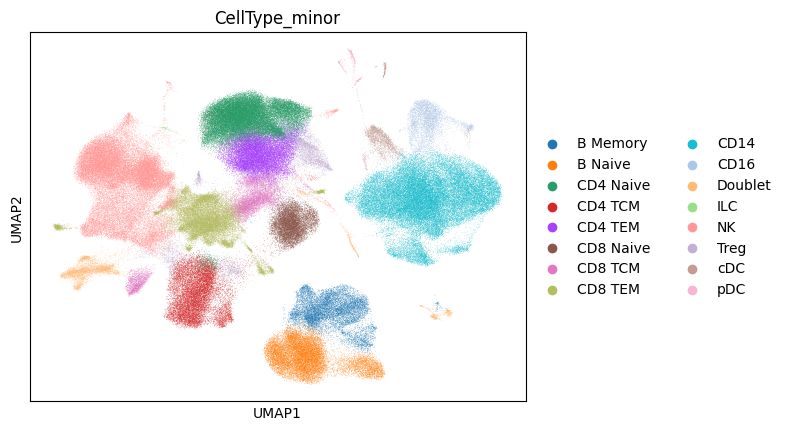

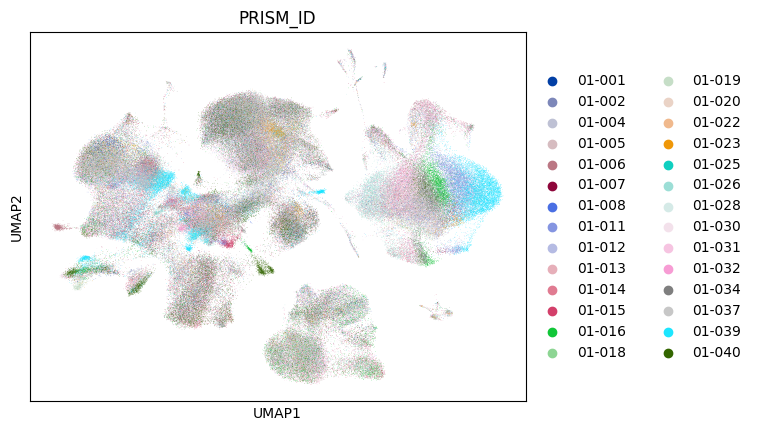

KeyError: 'Could not find key label in .var_names or .obs.columns.'

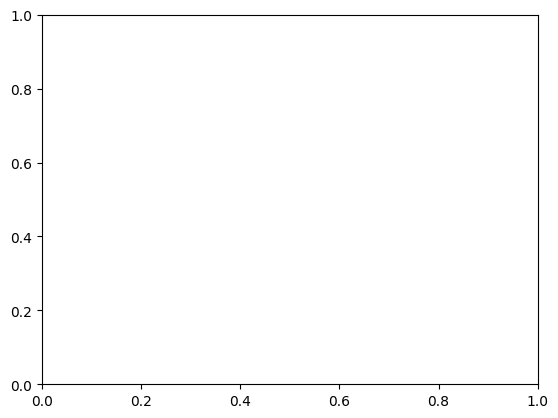

In [10]:
sc.pl.umap(asthma, color='CellType_minor', save='_celltype_minor.png')
sc.pl.umap(asthma, color='PRISM_ID', save='_prism_id.png')
sc.pl.umap(asthma, color='label', save='_label.png')

In [5]:

print(asthma.obs_keys())

for col in asthma.obs.columns:
    unique_values = asthma.obs[col].nunique()
    if unique_values <= 100 and "clus" not in col.lower():
        print(f"Column: {col}")
        print(asthma.obs[col].value_counts())
        print("\n")



['nCount_RNA', 'nFeature_RNA', 'barcodes', 'Sample_ID', 'batch', 'PRISM_ID', 'Biologics', 'TimePoint', 'percent.mt', 'RNA_snn_res.0.3', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1.2', 'RNA_snn_res.1.5', 'RNA_snn_res.1.8', 'seurat_clusters', 'twostep_aff_0.5', 'twostep_aff_0.4', 'twostep_aff_0.3', 'twostep_aff_0.2', 'twostep_aff_0.1', 'twostepclus2', 'twostepclus3', 'twostepclus4', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'twostep_aff_0.7', 'Azimuth_UMAP1', 'Azimuth_UMAP2', 'CellType_Major', 'CellType_minor', 'Treatment', 'Response', 'Response2']
Column: Sample_ID
Sample_ID
RH011013    19254
RH011022    18353
RH011036    17775
RH011034    17516
RH011031    16689
RH011009    16519
RH011011    16190
RH011012    16119
RH011028    15934
RH011026    15548
RH011035    14569
RH011007    11672
RH011029    10793
RH011006     8484
RH011018     46

In [18]:
"""
아래는
'Biologics' column의 value: mapping될 'Treatment' column의 value 딕셔너리이다.
mepolizumab	0
dupilumab	1
reslizumab	2


아래는
'PRISM_ID' column의 value: mapping될 'Response' column의 value 딕셔너리이다.
01-001	2
01-002	1
01-003	1
01-004	4
01-005	1
01-006	1
01-007	2
01-008	1
01-011	1
01-012	1
01-013	1
01-014	1
01-015	1
01-016	1
01-017	1
01-018	4
01-019	1
01-020	1
01-022	3
01-023	1
01-025	3
01-026	1
01-028	2
01-030	2
01-031	1
01-032	1
01-034	3
01-037	1
01-039	2
01-040	2
01-046	1
01-051	3
01-055	1

그 다음은 'Response' column의 value가 1,2이면 1, 3,4면 0로 바꿔서 'Response2' column을 새로 만들기
그리고 다시 './asthma/asthma_mapped.h5ad' 파일로 저장하기.
"""

treatment_mapping = {
    'mepolizumab': 2,
    'dupilumab': 1,
    'reslizumab': 0
}

response_mapping = {
    '01-001': 2, '01-002': 1, '01-003': 1, '01-004': 4, '01-005': 1,
    '01-006': 1, '01-007': 2, '01-008': 1, '01-011': 1, '01-012': 1,
    '01-013': 1, '01-014': 1, '01-015': 1, '01-016': 1, '01-017': 1,
    '01-018': 4, '01-019': 1, '01-020': 1, '01-022': 3, '01-023': 1,
    '01-025': 3, '01-026': 1, '01-028': 2, '01-030': 2, '01-031': 1,
    '01-032': 1, '01-034': 3, '01-037': 1, '01-039': 2, '01-040': 2,
    '01-046': 1, '01-051': 3, '01-055': 1
}

# Treatment: Biologics에서 매핑
asthma.obs['Treatment'] = asthma.obs['Biologics'].astype(str).str.strip().map(treatment_mapping)

# Response: PRISM_ID에서 매핑
asthma.obs['Response'] = asthma.obs['PRISM_ID'].astype(str).str.strip().map(response_mapping)

# Response2: NaN 방어 (Response가 없는 샘플은 NaN 유지)
asthma.obs['Response2'] = np.where(
    asthma.obs['Response'].isna(),
    np.nan,
    np.where(asthma.obs['Response'] > 2, 0, 1)
)

# DEG 안전: category로 저장
asthma.obs["Response2"] = asthma.obs["Response2"].astype("Int64")   # 0/1로 정수화(NA 있으면 Int64가 안전)
asthma.obs["Response2"] = asthma.obs["Response2"].astype(str).astype("category")  # '0','1' 카테고리로 고정
asthma.write_h5ad(asthma_path)


In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
asthma_path = './asthma/asthma_mapped.h5ad'
asthma = sc.read_h5ad(asthma_path)
"""
asthma data의 1/5만 sampling한다.
같은 patient 내에서 celltype 비율이 유지되도록 stratified sampling 한다. 
sampling 결과 50개 미만이면 제외한다.
output은 ./asthma/sample_asthma_data_mapped.h5ad
"""

from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in splitter.split(asthma.obs, asthma.obs['CellType_minor']):
    sampled_asthma = asthma[test_index]
sampled_asthma.write_h5ad('./asthma/sample_asthma_data_mapped.h5ad')


In [4]:
sampled_asthma

View of AnnData object with n_obs × n_vars = 105547 × 32002
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'Sample_ID', 'batch', 'PRISM_ID', 'Biologics', 'TimePoint', 'percent.mt', 'RNA_snn_res.0.3', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA_snn_res.1.2', 'RNA_snn_res.1.5', 'RNA_snn_res.1.8', 'seurat_clusters', 'twostep_aff_0.5', 'twostep_aff_0.4', 'twostep_aff_0.3', 'twostep_aff_0.2', 'twostep_aff_0.1', 'twostepclus2', 'twostepclus3', 'twostepclus4', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'twostep_aff_0.7', 'Azimuth_UMAP1', 'Azimuth_UMAP2', 'CellType_Major', 'CellType_minor', 'Treatment', 'Response', 'Response2'
    var: 'names'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    layers: 'counts_RNA'

In [6]:
for col in asthma.obs.columns:
    unique_values = asthma.obs[col].nunique()
    if unique_values <= 10 and "clus" not in col.lower():
        print(f"Column: {col}")
        print(asthma.obs[col].value_counts())
        print("\n")

Column: batch
batch
batch2    454379
batch1     73355
Name: count, dtype: int64


Column: Biologics
Biologics
reslizumab     318616
dupilumab      186138
mepolizumab     22980
Name: count, dtype: int64


Column: TimePoint
TimePoint
6M          268182
Baseline    259552
Name: count, dtype: int64


Column: predicted.celltype.l1
predicted.celltype.l1
CD4 T      165833
NK          93017
CD8 T       92602
Mono        88990
B           61477
other T     17655
DC           6383
other        1777
Name: count, dtype: int64


Column: CellType_Major
CellType_Major
T           270219
NK          100287
Monocyte     89936
B            60350
DC            6942
Name: count, dtype: int64


Column: Treatment
Treatment
0    318616
1    186138
2     22980
Name: count, dtype: int64


Column: Response
Response
1    343649
2    122171
3     51177
4     10737
Name: count, dtype: int64


Column: Response2
Response2
1    465820
0     61914
Name: count, dtype: int64




In [4]:
"""
'PRISM_ID' column in asthma has k unique values.
k= ?
"""
for col in asthma.obs.columns:
    unique_values = asthma.obs[col].nunique()
    print(f"Column: {col} (Unique values: {unique_values})")

"""
patient column in asthma has 11 unique values. and each patient is mapped to 4 different phenotypes. = 'phenotype' column has 4 unique values.
각 phenotype 당 patient 수는 다음과 같다.
"""
response_counts = asthma.obs.groupby('Response')['PRISM_ID'].nunique()
treatment_counts = asthma.obs.groupby('Treatment')['PRISM_ID'].nunique()
print(response_counts)
print(treatment_counts)

Column: nCount_RNA (Unique values: 14943)
Column: nFeature_RNA (Unique values: 4402)
Column: barcodes (Unique values: 527734)
Column: Sample_ID (Unique values: 53)
Column: batch (Unique values: 2)
Column: PRISM_ID (Unique values: 28)
Column: Biologics (Unique values: 3)
Column: TimePoint (Unique values: 2)
Column: percent.mt (Unique values: 315901)
Column: RNA_snn_res.0.3 (Unique values: 17)
Column: RNA_snn_res.0.5 (Unique values: 17)
Column: RNA_snn_res.0.8 (Unique values: 20)
Column: RNA_snn_res.1.2 (Unique values: 28)
Column: RNA_snn_res.1.5 (Unique values: 34)
Column: RNA_snn_res.1.8 (Unique values: 35)
Column: seurat_clusters (Unique values: 35)
Column: twostep_aff_0.5 (Unique values: 18)
Column: twostep_aff_0.4 (Unique values: 15)
Column: twostep_aff_0.3 (Unique values: 14)
Column: twostep_aff_0.2 (Unique values: 12)
Column: twostep_aff_0.1 (Unique values: 12)
Column: twostepclus2 (Unique values: 8)
Column: twostepclus3 (Unique values: 16)
Column: twostepclus4 (Unique values: 23)

In [25]:
ppi_path = 'PPI_human.tsv'
"""unique genes in PPI file"""
ppi_df = pd.read_csv(ppi_path, sep='\t')
unique_genes = set(ppi_df['protein1']).union(set(ppi_df['protein2']))
print(f"Number of unique genes in PPI file: {len(unique_genes)}")

Number of unique genes in PPI file: 19271


In [2]:
map_path = '9606.protein.aliases.v12.0.txt'
ppi_path = '9606.protein.links.v12.0.txt'
sequence_path = '9606.protein.sequences.v12.0.fa'

In [13]:
import pandas as pd
"""9606.protein.aliases.v12.0.txt 파일은 #string_protein_id	alias	source 3개의 column으로 이루어져 있다.
9606.protein.links.v12.0.txt 파일은 protein1 protein2 combined_score 3개의 column으로 이루어져 있다.
9606.protein.sequences.v12.0.fa 파일은 fasta 포맷으로 되어 있다.
예시:
>9606.ENSP00000000233
MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTIPTIGFNVETVEYKNICFTVWDVGGQDKIRPLWRH
YFQNTQGLIFVVDSNDRERVQESADELQKMLQEDELRDAVLLVFANKQDMPNAMPVSELTDKLGLQHLRSRTWYVQATCA
TQGTGLYDGLDWLSHELSKR

first, read '9606.protein.links.v12.0.txt' file and print the number of unique genes in protein1 and protein2 columns combined.
then, filter columns with combined score >= 700. leave only columns: protein1, protein2.

"""

ppi_df = pd.read_csv(ppi_path, sep=' ')
unique_genes = set(ppi_df['protein1']).union(set(ppi_df['protein2']))
print(f"Number of unique genes in PPI file: {len(unique_genes)}")
filtered_ppi_df = ppi_df[ppi_df['combined_score'] >= 700][['protein1', 'protein2']]



Number of unique genes in PPI file: 19622


In [14]:
"""
read 9606.protein.aliases.v12.0.txt and map the unique_genes to their 'KEGG_NAME's, and save the mapping to 'mapping.tsv'.
string_protein_id가 unique_genes에 있으면 source column이 'KEGG_NAME'인 alias를 찾아 mapping으로 사용한다. 
"""
alias_df = pd.read_csv(map_path, sep='\t', comment='#', names=['string_protein_id', 'alias', 'source'])
alias_df_kegg = alias_df[alias_df['source'] == 'KEGG_NAME']
alias_mapping = {}
for _, row in alias_df_kegg.iterrows():
    string_protein_id = row['string_protein_id']
    alias = row['alias']
    if string_protein_id in unique_genes:
        alias_mapping[string_protein_id] = alias
mapping_df = pd.DataFrame(list(alias_mapping.items()), columns=['string_protein_id', 'gene'])
mapping_df.to_csv('mapping.tsv', sep='\t', index=False)

In [16]:
"""save filtered_ppi_df to 'ppi_network.tsv' with mapped gene names using 'alias_mapping'"""

filtered_ppi_df['protein1'] = filtered_ppi_df['protein1'].map(alias_mapping)
filtered_ppi_df['protein2'] = filtered_ppi_df['protein2'].map(alias_mapping)
filtered_ppi_df = filtered_ppi_df.dropna(subset=['protein1', 'protein2'])
filtered_ppi_df = filtered_ppi_df[['protein1', 'protein2']]
filtered_ppi_df.to_csv('ppi_network.tsv', sep='\t', index=False)

In [ ]:
asthma_path= 'sample_asthma_data_filtered.h5ad'
asthma = sc.read_h5ad(asthma_path)
